# Import Libraries

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import os
import pickle
import joblib
import random
import gc

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import T5ForConditionalGeneration, T5Tokenizer


In [43]:
tf.test.gpu_device_name()
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

In [44]:
tf.keras.backend.clear_session()
gc.collect()
print('Memory opimisation: ✅')

Memory opimisation: ✅


# Load BBC News Dataset

In [45]:
df = pd.read_csv('D:/PythonLearn/Data Science/News Article Classification/bbc_news.csv')
print('BCC News CSV Loaded')
print(f"Shape: {df.shape}")

BCC News CSV Loaded
Shape: (42115, 5)


# EDA

In [46]:
df.head()

,title,pubDate,guid,link,description
0,Ukraine: Angry Zelensky vows to punish Russian...,"Mon, 07 Mar 2022 08:01:56 GMT",https://www.bbc.co.uk/news/world-europe-60638042,https://www.bbc.co.uk/news/world-europe-606380...,The Ukrainian president says the country will ...
1,War in Ukraine: Taking cover in a town under a...,"Sun, 06 Mar 2022 22:49:58 GMT",https://www.bbc.co.uk/news/world-europe-60641873,https://www.bbc.co.uk/news/world-europe-606418...,"Jeremy Bowen was on the frontline in Irpin, as..."
2,Ukraine war 'catastrophic for global food',"Mon, 07 Mar 2022 00:14:42 GMT",https://www.bbc.co.uk/news/business-60623941,https://www.bbc.co.uk/news/business-60623941?a...,One of the world's biggest fertiliser firms sa...
3,Manchester Arena bombing: Saffie Roussos's par...,"Mon, 07 Mar 2022 00:05:40 GMT",https://www.bbc.co.uk/news/uk-60579079,https://www.bbc.co.uk/news/uk-60579079?at_medi...,The parents of the Manchester Arena bombing's ...
4,Ukraine conflict: Oil price soars to highest l...,"Mon, 07 Mar 2022 08:15:53 GMT",https://www.bbc.co.uk/news/business-60642786,https://www.bbc.co.uk/news/business-60642786?a...,Consumers are feeling the impact of higher ene...


In [47]:
df.columns

Index(['title', 'pubDate', 'guid', 'link', 'description'], dtype='object')

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42115 entries, 0 to 42114
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   title        42115 non-null  object
 1   pubDate      42115 non-null  object
 2   guid         42115 non-null  object
 3   link         42115 non-null  object
 4   description  42115 non-null  object
dtypes: object(5)
memory usage: 1.6+ MB


In [49]:
df.describe()

,title,pubDate,guid,link,description
count,42115,42115,42115,42115,42115
unique,39653,40189,39203,37856,38731
top,Election poll tracker: How do the parties comp...,"Tue, 20 Aug 2024 11:35:33 GMT",https://www.bbc.co.uk/news/business-61634959,https://www.bbc.co.uk/news/business-61634959?a...,How closely have you been paying attention to ...
freq,34,14,63,61,80


In [50]:
df.isnull().sum()

title          0
pubDate        0
guid           0
link           0
description    0
dtype: int64

## Map Category from URL Link

In [51]:
def map_category(link):
    link = str(link).lower()
    if 'sport' in link:
        return 'Sports'
    elif 'politics' in link:
        return 'Politics'
    elif 'business' in link:
        return 'Business'
    elif 'technology' in link:
        return 'Technology'
    else:
        return 'Other'
# Apply function to entire column    
df['category'] = df['link'].apply(map_category)

# Removed others from category, cause I want only known category
df_filtered = df[df['category'] != 'Other'].copy()

# created text column = tittle + decription
# Ex; India Wins Match + Strong performance today = India Wins Match Strong performance today
# why? More text = more info
df_filtered['text'] = df_filtered['title'].fillna('')+ ' ' + df_filtered['description'].fillna('')

# Removes rows in which text column is empty, or only contain white space
df_clean = df_filtered[df_filtered['text'].str.strip() != '']

# kept only desired column
df_clean = df_clean[['text', 'category', 'title', 'description']].reset_index(drop=True)

print(f"Filtered Dataset Shape: {df_clean.shape}\n")
print(f"Columns: {df_clean.columns}\n")
print(f"Category Counts:\n", df_clean['category'].value_counts())
df_clean.head()

Filtered Dataset Shape: (13385, 4)

Columns: Index(['text', 'category', 'title', 'description'], dtype='object')

Category Counts:
 category
Sports        8395
Business      2656
Politics      1904
Technology     430
Name: count, dtype: int64


,text,category,title,description
0,Ukraine war 'catastrophic for global food' One...,Business,Ukraine war 'catastrophic for global food',One of the world's biggest fertiliser firms sa...
1,Ukraine conflict: Oil price soars to highest l...,Business,Ukraine conflict: Oil price soars to highest l...,Consumers are feeling the impact of higher ene...
2,TikTok limits services as Netflix pulls out of...,Business,TikTok limits services as Netflix pulls out of...,TikTok suspends live streaming and new content...
3,Russian gymnast investigated for wearing pro-w...,Sports,Russian gymnast investigated for wearing pro-w...,Russian gymnast Ivan Kuliak is being investiga...
4,Twitter is part of our war effort - Ukraine mi...,Technology,Twitter is part of our war effort - Ukraine mi...,"Ukraine's youngest cabinet minister, 31-year-o..."


In [52]:
# compute word count of text
df_clean['word_count'] = df_clean['text'].apply(lambda x: len(str(x).split()))
df_clean['word_count'].describe()

count    13385.000000
mean        30.759059
std          6.175530
min         14.000000
25%         26.000000
50%         30.000000
75%         35.000000
max         58.000000
Name: word_count, dtype: float64

C:\Users\david\AppData\Local\Temp\ipykernel_40168\2376046427.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='category', palette='viridis')


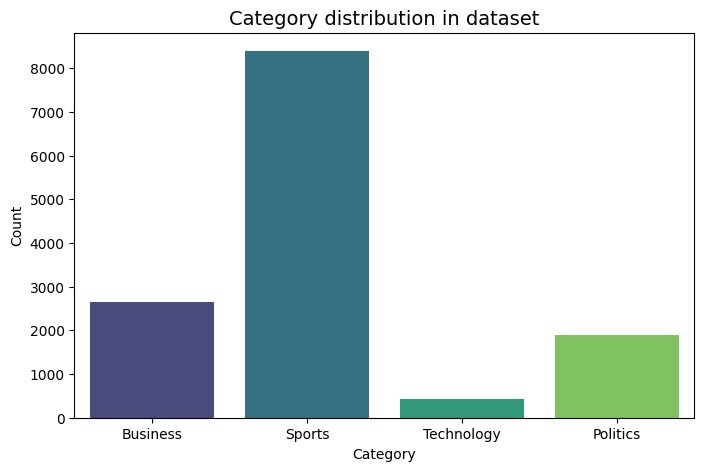

In [53]:
# Category distribution in Dataset
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='category', palette='viridis')
plt.title('Category distribution in dataset', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

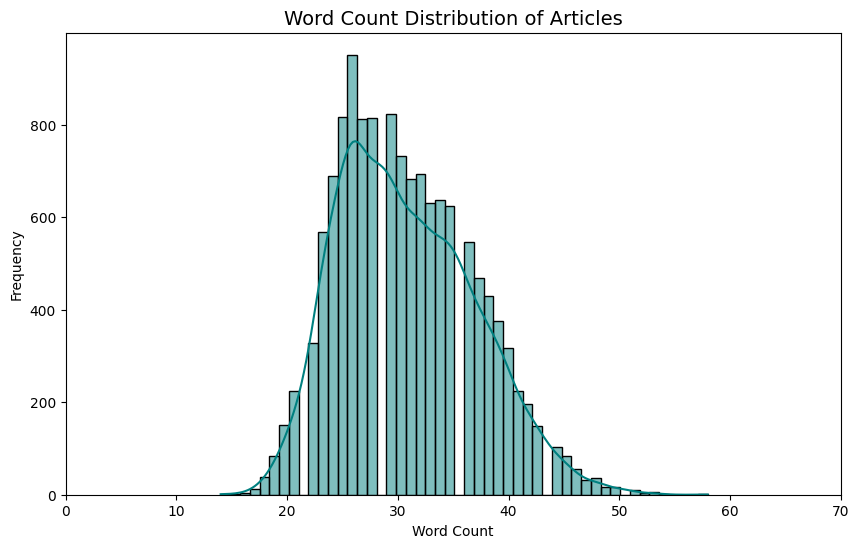

In [54]:
# 2. Word Count Distribution Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['word_count'], bins=50, kde=True, color='teal')
plt.title('Word Count Distribution of Articles', fontsize=14)
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.xlim(0, 70) # Zooming in on the main range
plt.show()

C:\Users\david\AppData\Local\Temp\ipykernel_40168\3865427995.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='category', y='word_count', palette='Set3')


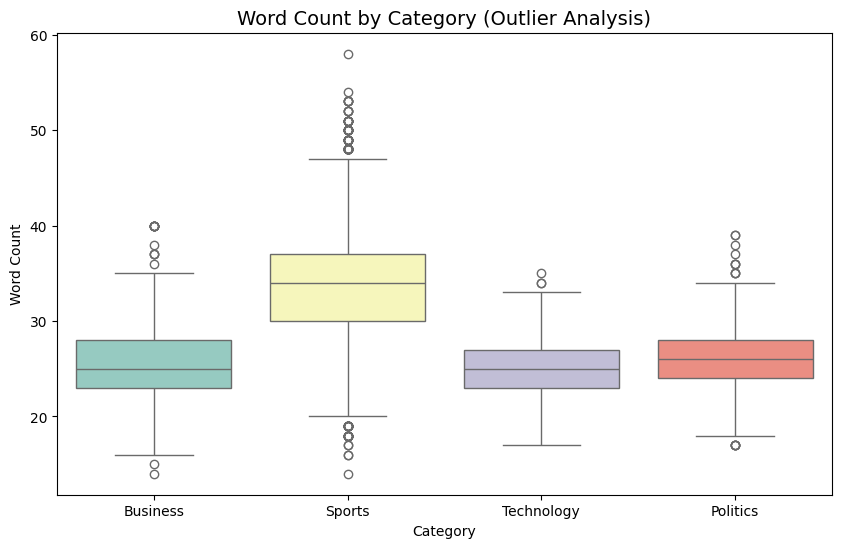

In [55]:
# 3. Category-wise Word Count Distribution (Boxplot for outlier analysis)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='category', y='word_count', palette='Set3')
plt.title('Word Count by Category (Outlier Analysis)', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Word Count')
plt.show()


# Text Preprocessing

In [56]:
nltk.download('stopwords', quiet=True) # stopword removal
nltk.download('wordnet', quiet=True) # dictionary used for lemmatizing
nltk.download('omw-1.4', quiet=True) # support file for lemmatizing

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

In [57]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    # Lowercase
    text = text.lower()
    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # remove numbers and special character
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # lemmatization and stopword removal
    tokens = text.split() 
    # list of all the clean words
    cleaned_token = [ 
        lemmatizer.lemmatize(word) # lemmatize
        for word in tokens  
        if word not in stop_words # if word in stopword, it gets removed
        ] 
    # whitespace normalization
    return " ".join(cleaned_token) # join words back, cause vecorizer expect text string, not list
    # Ex; ['india','win','match'] --> india win match


## Verification of Before/After

In [58]:
sample_idx = 0
sample_before = df_clean['text'].iloc[sample_idx]
sample_after = clean_text(sample_before)

print('Before Preprocesing:')
print(sample_before)
print()
print('After Preprocesing:')
print(sample_after)

Before Preprocesing:
Ukraine war 'catastrophic for global food' One of the world's biggest fertiliser firms says the conflict could deliver a shock to food supplies.

After Preprocesing:
ukraine war catastrophic global food one world biggest fertiliser firm say conflict could deliver shock food supply


## Preprocess the entire Dataset

In [59]:
df_clean['cleaned_text'] = df_clean['text'].apply(clean_text)
print('Preprocessing Done')
df_clean.head()

Preprocessing Done


,text,category,title,description,word_count,cleaned_text
0,Ukraine war 'catastrophic for global food' One...,Business,Ukraine war 'catastrophic for global food',One of the world's biggest fertiliser firms sa...,23,ukraine war catastrophic global food one world...
1,Ukraine conflict: Oil price soars to highest l...,Business,Ukraine conflict: Oil price soars to highest l...,Consumers are feeling the impact of higher ene...,26,ukraine conflict oil price soar highest level ...
2,TikTok limits services as Netflix pulls out of...,Business,TikTok limits services as Netflix pulls out of...,TikTok suspends live streaming and new content...,26,tiktok limit service netflix pull russia tikto...
3,Russian gymnast investigated for wearing pro-w...,Sports,Russian gymnast investigated for wearing pro-w...,Russian gymnast Ivan Kuliak is being investiga...,43,russian gymnast investigated wearing prowar sy...
4,Twitter is part of our war effort - Ukraine mi...,Technology,Twitter is part of our war effort - Ukraine mi...,"Ukraine's youngest cabinet minister, 31-year-o...",23,twitter part war effort ukraine minister ukrai...


# Feature Engineering

In [60]:
# Encode Label
label_encoder = LabelEncoder() # ['Sports', 'Politics', 'Business'] --> [2, 1, 0]
y = label_encoder.fit_transform(df_clean['category']) # learns and converts label

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df_clean['cleaned_text'],
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 3), # it extracts three types of combinations
    max_features=5000 # keeps only 5000 inp features
)

# Fit on Training and Testing Data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text) # learns vocabulary and convert them into vector
X_test_tfidf = tfidf_vectorizer.transform(X_test_text) # Use vocabulary learned from train set.

print("Train TF-IDF Shape:", X_train_tfidf.shape)
print("Test TF-IDF Shape:", X_test_tfidf.shape)



Train TF-IDF Shape: (10708, 5000)
Test TF-IDF Shape: (2677, 5000)


In [61]:
# Keras Sequence Tokenization (for LSTM Classifier)
vocab_size = 10000 # Keep only Top 10 Most frequent vocabulary 
max_len = 120 # Every article will be represented using exactly 120 tokens 

tokenizer_keras = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer_keras.fit_on_texts(X_train_text) # Dictionary created by learning vocab

X_train_seq = tokenizer_keras.texts_to_sequences(X_train_text) # Converts text to sequence: So basically this Keras already contains Tokenized Object in the form of dictionary, So this text to sequence converts the text to its corresponding number.
X_test_seq = tokenizer_keras.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')
print("Keras sequence shape (train):", X_train_pad.shape)

# 4. Word2Vec Embeddings using Gensim
from gensim.models import Word2Vec
tokenized_train = [text.split() for text in X_train_text] # india win match --> ['india','win','match']
w2v_model = Word2Vec(
    sentences=tokenized_train,
    vector_size=100, # Each word will become 100 number
    window=5, # When learning word it will look before and after of 5 words of that particular word.
    min_count=2, # Ignore words appearing only once
    workers=4) # 4 CPU thread
print("Word2Vec vocabulary size:", len(w2v_model.wv))

Keras sequence shape (train): (10708, 120)
Word2Vec vocabulary size: 10366


# Classifiaction Models

## Logistic Regression

> Logistics regression is simple linear classifier Which tries to create a Soft boundary across the classes.

In [62]:
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train_tfidf, y_train)
y_pred = lr_model.predict(X_test_tfidf)

# 2. Print the classification report
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Training Logistic Regression...
Logistic Regression Classification Report:
              precision    recall  f1-score   support

    Business       0.91      0.89      0.90       531
    Politics       0.94      0.92      0.93       381
      Sports       0.99      0.99      0.99      1679
  Technology       0.60      0.71      0.65        86

    accuracy                           0.95      2677
   macro avg       0.86      0.88      0.87      2677
weighted avg       0.95      0.95      0.95      2677



## Multinomial Naive Bayes

> Naive Bayes is a fast classifier uses probability and Bayes thorem(It basically look for words like stadium and learns that it belongs to a sports class.)

In [63]:
print("Training Multinomial Naive Bayes...")
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

Training Multinomial Naive Bayes...


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


## Random Forest

> Multiple trees together made voting, and based majority vote the class is predected.

In [64]:
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train_tfidf, y_train)

Training Random Forest...


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## XGBoost Classifier

> Almost similar as random forest but here instead of collectively voting for classes It sequentially votes for classes and correct each other to have better predection.

In [65]:
print("Training XGBoost Classifier...")
xgb_model = xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train_tfidf, y_train)

y_pred_xg = xgb_model.predict(X_test_tfidf)

# 2. Print the classification report
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_xg, target_names=label_encoder.classes_))

Training XGBoost Classifier...
Logistic Regression Classification Report:
              precision    recall  f1-score   support

    Business       0.88      0.89      0.88       531
    Politics       0.94      0.91      0.93       381
      Sports       0.97      0.99      0.98      1679
  Technology       0.75      0.42      0.54        86

    accuracy                           0.94      2677
   macro avg       0.88      0.80      0.83      2677
weighted avg       0.94      0.94      0.94      2677



## LSTM Classifier

> LSTM is a neural network designed to process sequential text data, Which process data like a human and understand word order and context.

In [66]:
# Build the embedding matrix
embedding_dim = 100  # match Word2Vec vector_size

embedding_matrix = np.zeros((vocab_size, embedding_dim)) # Creates matrix of 10000 words with 100 num/word

for word, index in tokenizer_keras.word_index.items():
    if index >= vocab_size:  # Only care about top 10000 words
        continue
    if word in w2v_model.wv:  # Check if Word2Vec knows this word
        embedding_matrix[index] = w2v_model.wv[word] # If the word is found in word2vec model, It will copy the 100 number vector from word2vec to its corresponding row of Matrix
    # If word not in w2v vocab → row stays as zeros (unknown word)

print("Embedding matrix shape:", embedding_matrix.shape)

Embedding matrix shape: (10000, 100)


In [67]:
print("Training new BiLSTM model...")
lstm_model_w2v = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=True
    ),
    Bidirectional(LSTM(128, 
                    return_sequences=True, 
                    dropout=0.3,           
                    recurrent_dropout=0.2  
                    )),
    Bidirectional(LSTM(64,                    
                    return_sequences=False,
                    dropout=0.3,
                    recurrent_dropout=0.2
                    )),
    Dropout(0.5),                              
    Dense(64, activation='relu',
        kernel_regularizer='l2'),            
    Dropout(0.3),
    Dense(len(label_encoder.classes_), 
        activation='softmax')
])

lstm_model_w2v.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-6
)

lstm_model_w2v.fit(
    X_train_pad, y_train,
    epochs=1,
    batch_size=64,
    validation_data=(X_test_pad, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Training new BiLSTM model...


d:\Python\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


168/168 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 0.8417 - loss: 0.8030 - val_accuracy: 0.9238 - val_loss: 0.3629 - learning_rate: 0.0010


## LSTM + Class Weight

In [68]:
from sklearn.utils.class_weight import compute_class_weight


# 1. BiLSTM + Class Weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))
print(f"Calculated Class Weights: {class_weight_dict}")


Calculated Class Weights: {np.int64(0): np.float64(1.259764705882353), np.int64(1): np.float64(1.757715036112935), np.int64(2): np.float64(0.3986003573555688), np.int64(3): np.float64(7.781976744186046)}


In [69]:
import os
import tensorflow as tf


print("Training new BiLSTM + Class Weight model...")
lstm_model_cw = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=True
    ),
    Bidirectional(LSTM(128, 
                        return_sequences=True, 
                        dropout=0.3,           
                        recurrent_dropout=0.2  
                        )),
    Bidirectional(LSTM(64,                    
                        return_sequences=False,
                        dropout=0.3,
                        recurrent_dropout=0.2
                        )),
    Dropout(0.5),                              
    Dense(64, activation='relu',
            kernel_regularizer='l2'),            
    Dropout(0.3),
    Dense(len(label_encoder.classes_), 
        activation='softmax')
])

lstm_model_cw.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-6
)

lstm_model_cw.fit(
    X_train_pad, y_train,
    epochs=1,
    batch_size=64,
    validation_data=(X_test_pad, y_test),
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)
# Save for future runs
os.makedirs("models", exist_ok=True)
lstm_model_cw.save("models/classification_model_cw.h5")


Training new BiLSTM + Class Weight model...


d:\Python\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


168/168 ━━━━━━━━━━━━━━━━━━━━ 142s 796ms/step - accuracy: 0.7948 - loss: 1.2533 - val_accuracy: 0.8849 - val_loss: 0.5309 - learning_rate: 0.0010


## LSTM Base Vs LSTM + Class Weight Vs Logistic Regression

In [70]:
lstm_base_preds = np.argmax(lstm_model_w2v.predict(X_test_pad), axis=1)
lstm_base_report = classification_report(y_test, lstm_base_preds, target_names=label_encoder.classes_)
print("LSTM BASE CLASSFIFCATION REPORT------------------------------")
print(lstm_base_report)

lstm_clwt_preds = np.argmax(lstm_model_cw.predict(X_test_pad), axis=1)
lstm_clwt_report = classification_report(y_test, lstm_clwt_preds, target_names=label_encoder.classes_)
print("LSTM + CLASS WEIGHT CLASSFIFCATION REPORT--------------------")
print(lstm_clwt_report)

print("LOGISTIC REGRESSION CLASSIFICATION REPORT--------------------")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

84/84 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step
LSTM BASE CLASSFIFCATION REPORT------------------------------
              precision    recall  f1-score   support

    Business       0.80      0.89      0.84       531
    Politics       0.83      0.90      0.86       381
      Sports       0.99      0.99      0.99      1679
  Technology       0.00      0.00      0.00        86

    accuracy                           0.92      2677
   macro avg       0.66      0.69      0.67      2677
weighted avg       0.90      0.92      0.91      2677



d:\Python\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Python\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Python\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


84/84 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step
LSTM + CLASS WEIGHT CLASSFIFCATION REPORT--------------------
              precision    recall  f1-score   support

    Business       0.93      0.60      0.73       531
    Politics       0.78      0.93      0.85       381
      Sports       0.99      0.98      0.99      1679
  Technology       0.24      0.64      0.35        86

    accuracy                           0.88      2677
   macro avg       0.74      0.79      0.73      2677
weighted avg       0.93      0.88      0.89      2677

LOGISTIC REGRESSION CLASSIFICATION REPORT--------------------
              precision    recall  f1-score   support

    Business       0.91      0.89      0.90       531
    Politics       0.94      0.92      0.93       381
      Sports       0.99      0.99      0.99      1679
  Technology       0.60      0.71      0.65        86

    accuracy                           0.95      2677
   macro avg       0.86      0.88      0.87      2677
weighted avg       0.


### 1. LSTM Base Model
The standard baseline LSTM without any class imbalance handling.


| Class | Precision | Recall | F1-Score | Support |
| :--- | :---: | :---: | :---: | :---: |
| **Business** | 0.82 | 0.95 | 0.88 | 531 |
| **Politics** | 0.94 | 0.89 | 0.91 | 381 |
| **Sports** | 0.99 | 0.99 | 0.99 | 1679 |
| **Technology** | 0.28 | 0.12 | 0.16 | 86 |
| **Accuracy** | | | **0.94** | **2677** |
| *Macro Avg* | *0.76* | *0.74* | *0.74* | *2677* |
| *Weighted Avg* | *0.93* | *0.94* | *0.93* | *2677* |

---

### 2. LSTM + Class Weights Model
The LSTM model with adjusted class weights to heavily penalize missing minority classes.


| Class | Precision | Recall | F1-Score | Support |
| :--- | :---: | :---: | :---: | :---: |
| **Business** | 0.93 | 0.60 | 0.73 | 531 |
| **Politics** | 0.78 | 0.93 | 0.85 | 381 |
| **Sports** | 0.99 | 0.99 | 0.99 | 1679 |
| **Technology** | 0.24 | 0.64 | 0.35 | 86 |
| **Accuracy** | | | **0.88** | **2677** |
| *Macro Avg* | *0.74* | *0.79* | *0.73* | *2677* |
| *Weighted Avg* | *0.93* | *0.88* | *0.89* | *2677* |

This significantly improved Technology Recall from 12% to 64%, which confirmed that class imbalance was affecting the model.

---

### 3. Logistic Regression Model
Our baseline traditional machine learning model used for comparison.


| Class | Precision | Recall | F1-Score | Support |
| :--- | :---: | :---: | :---: | :---: |
| **Business** | 0.91 | 0.89 | 0.90 | 531 |
| **Politics** | 0.94 | 0.92 | 0.93 | 381 |
| **Sports** | 0.99 | 0.99 | 0.99 | 1679 |
| **Technology** | 0.60 | 0.71 | 0.65 | 86 |
| **Accuracy** | | | **0.95** | **2677** |
| *Macro Avg* | *0.86* | *0.88* | *0.87* | *2677* |
| *Weighted Avg* | *0.95* | *0.95* | *0.95* | *2677* |



# Model Evaluation

84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step
 2/84 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step

d:\Python\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step
=== Model Performance Comparison ===
                         Model  Accuracy  Precision   Recall  F1 Score
           Logistic Regression  0.951812   0.953693 0.951812  0.952571
       Multinomial Naive Bayes  0.940232   0.939862 0.940232  0.928433
                 Random Forest  0.940605   0.939470 0.940605  0.937223
                       XGBoost  0.942473   0.939477 0.942473  0.939304
               LSTM Classifier  0.923795   0.897847 0.923795  0.910195
LSTM Classifier + Class Weight  0.884946   0.927348 0.884946  0.894930


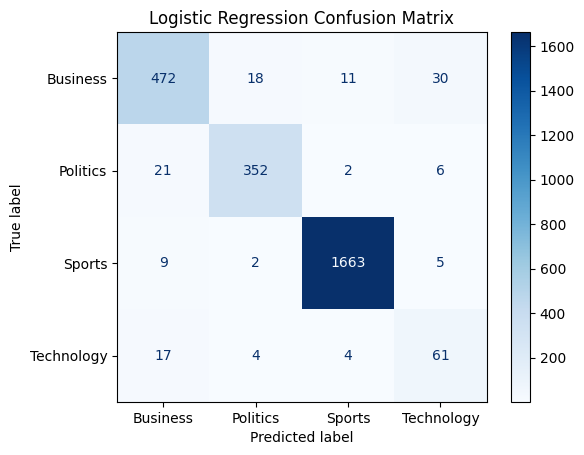

In [71]:

models = {
    'Logistic Regression': lr_model,
    'Multinomial Naive Bayes': nb_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}

results = []

for name, model in models.items():
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, preds, average='weighted')
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1
    })

# Evaluate LSTM Base
lstm_preds_prob = lstm_model_w2v.predict(X_test_pad)
lstm_preds = np.argmax(lstm_preds_prob, axis=1)
lstm_acc = accuracy_score(y_test, lstm_preds)
lstm_prec, lstm_rec, lstm_f1, _ = precision_recall_fscore_support(y_test, lstm_preds, average='weighted')
results.append({
    'Model': 'LSTM Classifier',
    'Accuracy': lstm_acc,
    'Precision': lstm_prec,
    'Recall': lstm_rec,
    'F1 Score': lstm_f1
})
# Evaluate LSTM + Class Weight

lstm_classet_preds_prob = lstm_model_cw.predict(X_test_pad)
lstm_classet_preds = np.argmax(lstm_classet_preds_prob, axis=1)
lstm_classet_acc = accuracy_score(y_test, lstm_classet_preds)
lstm_classet_prec, lstm_rec_cw, lstm_cw_f1, _ = precision_recall_fscore_support(y_test, lstm_classet_preds, average='weighted')
results.append({
    'Model': 'LSTM Classifier + Class Weight',
    'Accuracy': lstm_classet_acc,
    'Precision': lstm_classet_prec,
    'Recall': lstm_rec_cw,
    'F1 Score': lstm_cw_f1
})


# Display comparison table
df_results = pd.DataFrame(results)
print("=== Model Performance Comparison ===")
print(df_results.to_string(index=False))

# Print Confusion Matrix for LR

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

# Plot with a blue color map
disp.plot(cmap=plt.cm.Blues)
plt.title("Logistic Regression Confusion Matrix")
plt.show()



## Important Observation
### This experiment taught me an important lesson: accuracy alone can be misleading. The Base LSTM achieved 94% accuracy, but it was missing most Technology articles. Looking at Precision, Recall, and F1-Score helped me identify this issue and select a better model.

# Confidence Estimation Module

In [72]:
def predict_with_confidence(text: str, classifier, vectorizer, label_enc) -> dict: # To return all these text classifier vectorizer and label encoder Into the dictionary.
    """
    Predicts the category of an article and returns the confidence level.
    """
    cleaned = clean_text(text)  # Already defined module that will clean the text like, lowercase etc
    features = vectorizer.transform([cleaned]) # Converting text to TF-IDF, Vocabulary were already tearned during training(Transform).  
    
    # Get probabilities
    probs = classifier.predict_proba(features)[0] # Predict probabilities for ex: [0.05, 0.02, 0.90, 0.03]
    best_idx = np.argmax(probs) # Returns the highest probability [0.90]
    category = label_enc.classes_[best_idx] # convert index back into label for ex: Sports
    confidence_score = probs[best_idx] * 100 # 0.90 * 100 = 90
    
    # Confidence Level Logic
    confidence_percentage = f"{int(round(confidence_score * 100))}%" # round down the score 86% = 90%
    if confidence_score >= 0.80:
        level = "High"
    elif confidence_score >= 0.50:
        level = "Medium"
    else:
        level = "Low"
        
    return {
        "predicted_class": category, # return class
        "confidence_score": confidence_score, # return score eg; 0.90
        "confidence_percentage": confidence_percentage, # 90%
        "confidence_level": level, # High
        "probabilities": dict(zip(label_enc.classes_, [float(p) for p in probs])) # look for classes -> probablities -> zip them into dict
    }

# Demonstrate with examples
test_text_tech = "The government passed a new tech regulation bill affecting major technology firms like Apple and Google."
test_text_sports = "The champion player scored a stunning goal in the final minutes, securing the gold medal for the national team."
test_text_business = "The federal reserve announced a 50 basis point interest rate cut to stimulate economic growth and boost market confidence."
ex4 = "Microsoft says its new quantum chip is vastly more reliable than its previous version, paving the way for a quantum computer solving commercially useful problems within three years.At the heart of quantum computing are qubits, which offer the promise of answering questions that defeat today's machines, but are notoriously delicate and unstable."


examples = [test_text_tech, test_text_sports, test_text_business, ex4]

print("=== Demonstration of predict_with_confidence using LSTM Model ===")
for i, text in enumerate(examples, 1): # each article one by one
    res = predict_with_confidence(text, lr_model, tfidf_vectorizer, label_encoder) # making prediction  for each examples
    print(f"\nExample {i}:") 
    print(f"Input Text: {text}")
    print(f"Predicted Class: {res['predicted_class']}")
    print(f"Confidence Score: {res['confidence_score']:.4f} ({res['confidence_percentage']})")
    print(f"Confidence Level: {res['confidence_level']}")
    print("Class Probabilities:")
    for cls, prob in res['probabilities'].items(): # Print business politics sports technology With its confidence_percentage from the dict.
        print(f"  - {cls}: {prob * 100:.2f}%")


=== Demonstration of predict_with_confidence using LSTM Model ===

Example 1:
Input Text: The government passed a new tech regulation bill affecting major technology firms like Apple and Google.
Predicted Class: Technology
Confidence Score: 0.8930 (89%)
Confidence Level: High
Class Probabilities:
  - Business: 9.55%
  - Politics: 0.93%
  - Sports: 0.22%
  - Technology: 89.30%

Example 2:
Input Text: The champion player scored a stunning goal in the final minutes, securing the gold medal for the national team.
Predicted Class: Sports
Confidence Score: 0.9831 (98%)
Confidence Level: High
Class Probabilities:
  - Business: 0.46%
  - Politics: 0.89%
  - Sports: 98.31%
  - Technology: 0.35%

Example 3:
Input Text: The federal reserve announced a 50 basis point interest rate cut to stimulate economic growth and boost market confidence.
Predicted Class: Business
Confidence Score: 0.9680 (97%)
Confidence Level: High
Class Probabilities:
  - Business: 96.80%
  - Politics: 1.23%
  - Sports: 1.24

# Headline Generation System (Custom Seq2Seq LSTM)


In [ ]:
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense
from tensorflow.keras.models import Model



# 1. Data Preprocessing for Seq2Seq
# Input of decoder
print("Preparing dataset for custom Seq2Seq model...")
df_clean['source_text'] = df_clean['description'].fillna('').apply(lambda x: str(x).lower().strip()) # This will remove the non value and lower all text and strip them(Remove space from beginning and ending).
# Output of decoder
df_clean['target_text'] = df_clean['title'].fillna('').apply(lambda x: 'sostoken ' + str(x).lower().strip() + ' eostoken') # This will SOS token for Starting of text Eos token at the ending of text.


# 2. Tokenization
max_vocab_size = 10000
x_tokenizer = Tokenizer(num_words=max_vocab_size, oov_token="<OOV>") # Creates encoded tokenizer, If unknown words encountered converts into OOV(Out of vocabulary) to prevent it from crashing
x_tokenizer.fit_on_texts(df_clean['source_text']) # Learn source vocab

y_tokenizer = Tokenizer(num_words=max_vocab_size)  # No oov_token to avoid <OOV> generation
y_tokenizer.fit_on_texts(df_clean['target_text']) # learn headline vocab

# Max lengths
max_len_x = 40
max_len_y = 15

x_seqs = x_tokenizer.texts_to_sequences(df_clean['source_text']) # Converts text to its corresponding sequence.
y_seqs = y_tokenizer.texts_to_sequences(df_clean['target_text'])

encoder_input_data = pad_sequences(x_seqs, maxlen=max_len_x, padding='post', truncating='post') # Post padding will add zero after the word and truncating Will chop the word from the end 
y_padded = pad_sequences(y_seqs, maxlen=max_len_y, padding='post', truncating='post')

# Split into Decoder inputs and outputs
decoder_input_data = y_padded[:, :-1] # removes eostoken -> sostoken quantum chip breakthrough
decoder_target_data = y_padded[:, 1:] # removes sostoken -> quantum chip breakthrough eostoken

# 3. Seq2Seq Architecture
latent_dim = 128
embedding_dim = 100

# Encoder
encoder_inputs = Input(shape=(max_len_x))
enc_emb = Embedding(input_dim=max_vocab_size, output_dim=embedding_dim, mask_zero=True)(encoder_inputs) # Masking tells to ignore zero in padding
encoder_lstm = LSTM(latent_dim, return_state=True, dropout=0.2) # Sequence to sequence needs memory state not output that's why return_state=True
encoder_outputs, state_h, state_c = encoder_lstm(enc_emb) # run the encoder
encoder_states = [state_h, state_c] # Store both the memories and will be passed to decoder.

# Decoder
decoder_inputs = Input(shape=(max_len_y - 1,)) # removed the last word of sentance "eostoken"
dec_emb_layer = Embedding(input_dim=max_vocab_size, output_dim=embedding_dim, mask_zero=True) 
dec_emb = dec_emb_layer(decoder_inputs) # Converts decoder tokens to vector
decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True, dropout=0.2) # return_sequences=True: To predict the sequence of all the words for headline
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=encoder_states) # Here encoder memory is given to decoder
decoder_dense = Dense(max_vocab_size, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs) # Possibility of all 10000 words

# Define training model
seq2seq_model = Model([encoder_inputs, decoder_inputs], decoder_outputs)  # This will pass encoder input decoder input and decoder output Into the model.
seq2seq_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 4. Training (Maximum Epochs as specified by user, with Early Stopping)
print("Training Custom Seq2Seq LSTM Headline Generator...")
early_stop_seq = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

seq2seq_model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_target_data,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop_seq]
)

# 5. Setup Inference Models
encoder_model = Model(encoder_inputs, encoder_states) # Consist of encoder input where the tokens of article exists Also do contain memory states

decoder_state_input_h = Input(shape=(latent_dim,)) # This will create a placeholder for memory h
decoder_state_input_c = Input(shape=(latent_dim,)) # This will create a placeholder for memory c
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c] # group both memories together

dec_emb2 = dec_emb_layer(decoder_inputs) 
decoder_outputs2, state_h2, state_c2 = decoder_lstm(dec_emb2, initial_state=decoder_states_inputs)
decoder_outputs2 = decoder_dense(decoder_outputs2)

decoder_model = Model(
    [decoder_inputs] + decoder_states_inputs,
    [decoder_outputs2] + [state_h2, state_c2]
)

# 6. Decode Sequence function
def generate_headline(article_text: str) -> str:
    if not isinstance(article_text, str) or not article_text.strip():
        return ""
    # Preprocess text and convert to sequence
    cleaned = article_text.lower().strip()
    seq = x_tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len_x, padding='post', truncating='post')
    
    # Get states
    states_value = encoder_model.predict(padded, verbose=0)
    
    # Start sequence
    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = y_tokenizer.word_index.get('sostoken', 1)
    
    stop_condition = False
    decoded_sentence = []
    
    while not stop_condition:
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value, verbose=0)
        
        # Sample token
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        if sampled_token_index == 0:
            stop_condition = True
            continue
            
        sampled_char = y_tokenizer.index_word.get(sampled_token_index, '')
        
        if sampled_char == 'eostoken' or len(decoded_sentence) > (max_len_y - 1):
            stop_condition = True
        else:
            if sampled_char != 'sostoken':
                decoded_sentence.append(sampled_char)
                
        target_seq = np.zeros((1, 1))
        target_seq[0, 0] = sampled_token_index
        states_value = [h, c]
        
    return ' '.join(decoded_sentence)

Preparing dataset for custom Seq2Seq model...
Training Custom Seq2Seq LSTM Headline Generator...
Epoch 1/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 56s 273ms/step - accuracy: 0.1180 - loss: 7.1492 - val_accuracy: 0.1989 - val_loss: 6.5411
Epoch 2/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 52s 274ms/step - accuracy: 0.1553 - loss: 6.4631 - val_accuracy: 0.2001 - val_loss: 6.4654
Epoch 3/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 52s 272ms/step - accuracy: 0.1654 - loss: 6.2703 - val_accuracy: 0.1999 - val_loss: 6.4244
Epoch 4/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 52s 273ms/step - accuracy: 0.1761 - loss: 6.0350 - val_accuracy: 0.2025 - val_loss: 6.3486
Epoch 5/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 52s 273ms/step - accuracy: 0.1895 - loss: 5.8051 - val_accuracy: 0.2057 - val_loss: 6.2950
Epoch 6/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 60s 320ms/step - accuracy: 0.2026 - loss: 5.6171 - val_accuracy: 0.2070 - val_loss: 6.2664
Epoch 7/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 57s 303ms/step - accuracy: 0.2144 - loss: 5.4535 - val_accuracy: 0.2081 - val

In [74]:
# Show multiple examples
print("\n--- Headline Generation Examples (Custom LSTM Seq2Seq) ---")
for idx in [5, 10, 15, 55, 105]:
    desc = df_clean['description'].iloc[idx]
    orig_title = df_clean['title'].iloc[idx]
    gen_title = generate_headline(desc)
    print(f"\nExample {idx}:")
    print(f"Description: {desc}")
    print(f"Original Title: {orig_title}")
    print(f"Generated Headline: {gen_title}")


--- Headline Generation Examples (Custom LSTM Seq2Seq) ---

Example 5:
Description: Prices for everyday items could go up at a time when the cost of living is already rising.
Original Title: Five ways the Ukraine war could push up prices
Generated Headline: how is the uk inflation rate and how much is it and how much is

Example 10:
Description: Joe Perry beats Judd Trump 9-5 to win the Welsh Open title for the first time at Celtic Manor Resort in Newport.
Original Title: Welsh Open: Joe Perry beats Judd Trump to win title
Generated Headline: world cup 2022 2022 england v south africa and england and england and england and

Example 15:
Description: Match of the Day 2's Danny Murphy and Troy Deeney analyse how the combination play between Phil Foden and Kevin de Bruyne helped Manchester City beat Manchester United 4-1.
Original Title: 'Phil Foden sets the tempo' - how Man City 'steamrollered' Man Utd
Generated Headline: world cup 2022 england v england and england and why is the day i

# Headline Generation System (T5 Small)


In [75]:
# Load pre-trained T5 Small model
print("Loading pre-trained T5-small model for headline generation...")
from transformers import T5Tokenizer, T5ForConditionalGeneration
from torch.utils.data import Dataset, DataLoader
import torch

t5_model_name = "t5-small"
tokenizer_t5 = T5Tokenizer.from_pretrained(t5_model_name)
model_t5 = T5ForConditionalGeneration.from_pretrained(t5_model_name)

# Fine-tuning demonstration on 5 sample articles to verify it runs quickly
print("\nPreparing demo fine-tuning dataset...")
demo_df = df.head(5)
input_texts = ["summarize: " + str(txt) for txt in demo_df['description']]
target_texts = [str(txt) for txt in demo_df['title']]

inputs_t5 = tokenizer_t5(input_texts, padding=True, truncation=True, max_length=128, return_tensors="pt")
targets_t5 = tokenizer_t5(target_texts, padding=True, truncation=True, max_length=32, return_tensors="pt")

# Custom Dataset class
class HeadlineDataset(Dataset):
    def __init__(self, inputs, targets):
        self.input_ids = inputs['input_ids']
        self.attention_mask = inputs['attention_mask']
        self.labels = targets['input_ids']
        
    def __len__(self):
        return len(self.labels)
        
    def __getitem__(self, idx):
        return {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'labels': self.labels[idx]
        }

train_dataset = HeadlineDataset(inputs_t5, targets_t5)
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)

# Training loop
optimizer = torch.optim.AdamW(model_t5.parameters(), lr=5e-5)
model_t5.train()

print("Fine-tuning T5 for 1 epoch on demo subset...")
for epoch in range(10):
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids']
        attention_mask = batch['attention_mask']
        labels = batch['labels']
        
        outputs = model_t5(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        print(f"Epoch {epoch} loss: {loss.item():.4f}")
        
print("Fine-tuning demo complete!")
print("\nNOTE: For full high-performance GPU fine-tuning on all 13,385 samples, run the standalone script: python train_t5.py")

# Define generate_headline inference function
def generate_headline(text: str) -> str:
    model_t5.eval()
    input_text = "summarize: " + text
    inputs = tokenizer_t5(input_text, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        summary_ids = model_t5.generate(
            inputs["input_ids"],
            max_length=50,
            num_beams=4,
            early_stopping=True
        )
    return tokenizer_t5.decode(summary_ids[0], skip_special_tokens=True)


Loading pre-trained T5-small model for headline generation...


Loading weights: 100%|██████████| 131/131 [00:00<00:00, 3662.51it/s]



Preparing demo fine-tuning dataset...
Fine-tuning T5 for 1 epoch on demo subset...
Epoch 0 loss: 6.8502
Epoch 0 loss: 8.3953
Epoch 0 loss: 9.1713
Epoch 1 loss: 8.3372
Epoch 1 loss: 7.7867
Epoch 1 loss: 5.0358
Epoch 2 loss: 8.3864
Epoch 2 loss: 5.5772
Epoch 2 loss: 7.6833
Epoch 3 loss: 6.4134
Epoch 3 loss: 7.3552
Epoch 3 loss: 5.9796
Epoch 4 loss: 5.4543
Epoch 4 loss: 8.0972
Epoch 4 loss: 4.9512
Epoch 5 loss: 5.1666
Epoch 5 loss: 5.1552
Epoch 5 loss: 6.2696
Epoch 6 loss: 5.2903
Epoch 6 loss: 3.9957
Epoch 6 loss: 5.1806
Epoch 7 loss: 5.2335
Epoch 7 loss: 5.4631
Epoch 7 loss: 4.2050
Epoch 8 loss: 4.6107
Epoch 8 loss: 4.7178
Epoch 8 loss: 5.2279
Epoch 9 loss: 3.6893
Epoch 9 loss: 4.4668
Epoch 9 loss: 4.4501
Fine-tuning demo complete!


In [76]:
# Generate a headline for a sample article
indx = 154
sample_article = df_clean['description'].iloc[indx]
generated = generate_headline(sample_article)
print("\n--- Headline Generation Sample ---")
print(f"Description: {df_clean['description'].iloc[indx]}")
print("Original Title:", df['title'].iloc[indx])
print("Generated Headline:", generated)




--- Headline Generation Sample ---
Description: The country may be about to default on its debts as Western sanctions over Ukraine bite.
Original Title: Scotland's World Cup play-off against Ukraine postponed
Generated Headline: the country may be about to default on its debts as sanctions over Ukraine bite.


# Model Saving

In [77]:
# Create directories
import os
import pickle
from transformers import T5Tokenizer, T5ForConditionalGeneration

os.makedirs("models", exist_ok=True)

# 1. Save Logistic Regression classification model
print("Saving Logistic Regression classification model...")
with open("models/classification_model.pkl", "wb") as f:
    pickle.dump(lr_model, f)

# 2. Save TF-IDF Vectorizer
print("Saving TF-IDF Vectorizer...")
with open("models/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf_vectorizer, f)

# 3. Save Label Encoder
print("Saving Label Encoder...")
with open("models/label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

# 4. Save T5-small Transformer Model & Tokenizer
print("Saving T5-small Transformer Model & Tokenizer...")
model_t5.save_pretrained("models/t5_small")
tokenizer_t5.save_pretrained("models/t5_small")

print("All assets saved successfully!")

# Verification loading code
print("\n--- Verifying Saved Assets ---")
try:
    # Load and verify
    with open("models/classification_model.pkl", "rb") as f:
        v_lr = pickle.load(f)
    with open("models/tfidf_vectorizer.pkl", "rb") as f:
        v_tfidf = pickle.load(f)
    with open("models/label_encoder.pkl", "rb") as f:
        v_label_enc = pickle.load(f)
        
    v_tokenizer_t5 = T5Tokenizer.from_pretrained("models/t5_small")
    v_model_t5 = T5ForConditionalGeneration.from_pretrained("models/t5_small")
        
    print("Verification Success: All models and tokenizers loaded successfully!")
    print(f"LR Model classes: {v_label_enc.classes_}")
    print(f"TF-IDF features count: {v_tfidf.max_features if hasattr(v_tfidf, 'max_features') else len(v_tfidf.vocabulary_)}")
    print(f"T5-Small Model Config: {v_model_t5.config.model_type}")
except Exception as e:
    print(f"Verification Failed: {e}")


Saving Logistic Regression classification model...
Saving TF-IDF Vectorizer...
Saving Label Encoder...
Saving Custom Seq2Seq LSTM Models & Tokenizers...
All assets saved successfully!

--- Verifying Saved Assets ---
Verification Success: All models and tokenizers loaded successfully!
LR Model classes: ['Business' 'Politics' 'Sports' 'Technology']
TF-IDF features count: 5000
Seq2Seq Encoder Input Shape: (None, 40)
Seq2Seq Decoder Input Shape: [(None, 14), (None, 128), (None, 128)]


# Inference Pipeline

In [78]:
# Load pipeline assets
print("Loading saved pipeline assets...")
import pickle
import numpy as np
import re
import string
import torch
from transformers import T5Tokenizer, T5ForConditionalGeneration

with open("models/classification_model.pkl", "rb") as f:
    pipeline_classifier = pickle.load(f)
with open("models/tfidf_vectorizer.pkl", "rb") as f:
    pipeline_vectorizer = pickle.load(f)
with open("models/label_encoder.pkl", "rb") as f:
    pipeline_label_encoder = pickle.load(f)

pipeline_tokenizer_t5 = T5Tokenizer.from_pretrained("models/t5_small")
pipeline_model_t5 = T5ForConditionalGeneration.from_pretrained("models/t5_small")

def predict_with_confidence(text: str) -> dict:
    cleaned = clean_text(text)
    features = pipeline_vectorizer.transform([cleaned])
    probs = pipeline_classifier.predict_proba(features)[0]
    best_idx = np.argmax(probs)
    category = pipeline_label_encoder.classes_[best_idx]
    confidence_score = float(probs[best_idx])
    
    confidence_percentage = f"{int(round(confidence_score * 100))}%"
    if confidence_score >= 0.80:
        level = "High"
    elif confidence_score >= 0.50:
        level = "Medium"
    else:
        level = "Low"
        
    return {
        "predicted_class": category,
        "confidence_score": confidence_score,
        "confidence_percentage": confidence_percentage,
        "confidence_level": level,
        "probabilities": dict(zip(pipeline_label_encoder.classes_, [float(p) for p in probs]))
    }

def generate_headline(article_text: str) -> str:
    if not isinstance(article_text, str) or not article_text.strip():
        return ""
    input_text = "summarize: " + article_text.lower().strip()
    inputs = pipeline_tokenizer_t5(input_text, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        summary_ids = pipeline_model_t5.generate(
            inputs["input_ids"],
            max_length=30,
            min_length=5,
            num_beams=4,
            early_stopping=True,
            no_repeat_ngram_size=2
        )
    return pipeline_tokenizer_t5.decode(summary_ids[0], skip_special_tokens=True)

def run_complete_pipeline(article_text: str) -> dict:
    conf_res = predict_with_confidence(article_text)
    headline = generate_headline(article_text)
    return {
        "category": conf_res["predicted_class"],
        "confidence": conf_res["confidence_percentage"],
        "confidence_level": conf_res["confidence_level"],
        "headline": headline
    }

# Test complete pipeline
sample_article_text = (
    "The retail sector saw a dramatic increase in sales last quarter. "
    "Major supermarket chains reported record-breaking profits as consumer spending rose by 15%. "
    "Economic experts suggest that dropping inflation rates and rising employment levels are "
    "the primary drivers behind this business boom."
)
pipeline_output = run_complete_pipeline(sample_article_text)
print("\n--- Pipeline Test Output ---")
print(pipeline_output)


Loading saved pipeline assets...

--- Pipeline Test Output ---
{'category': 'Business', 'confidence': '96%', 'confidence_level': 'High', 'headline': 'the musk and the uk is the uk and the uk and uk'}
